# Laporan Evaluasi & Visualisasi Sistem CBR
---
Laporan ini berisi tabel metrik performa model, visualisasi *bar chart*, dan analisis kegagalan (*error analysis*) sesuai dengan **Tahap 5** instruksi proyek.

## 1. Tabel Metrik Perbandingan Model
Pada tahap ini, kita memuat metrik dari metode **TF-IDF + Cosine Similarity** yang telah kita buat sebelumnya, lalu kita akan membandingkannya dengan metode **Machine Learning (SVM)** untuk melihat perbedaan performanya.

In [1]:
import pandas as pd
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load Data Evaluasi TF-IDF yang sudah ada
metrics_csv = '../data/eval/retrieval_metrics.csv'
df_metrics = pd.read_csv(metrics_csv)

# 2. Membuat Pembanding Model (SVM)
train_df = pd.read_csv('../data/processed/train_cases.csv')
test_df = pd.read_csv('../data/processed/test_cases.csv')

train_df['ringkasan_fakta'] = train_df['ringkasan_fakta'].fillna("")
test_df['ringkasan_fakta'] = test_df['ringkasan_fakta'].fillna("")
train_df['pasal'] = train_df['pasal'].fillna("Tidak Diketahui")
test_df['pasal'] = test_df['pasal'].fillna("Tidak Diketahui")

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_df['ringkasan_fakta'])
y_train = train_df['pasal']

X_test = vectorizer.transform(test_df['ringkasan_fakta'])
y_test = test_df['pasal']

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Hitung Metrik SVM
svm_metrics = {
    'Model': 'SVM Classifier',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'F1_Score': f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)
}

# Gabungkan dan tampilkan Tabel
df_metrics = pd.concat([df_metrics, pd.DataFrame([svm_metrics])], ignore_index=True)
display(df_metrics)

c:\Users\Nabil\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:755: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,Model,Accuracy,Precision,Recall,F1_Score
0,TF-IDF + Cosine Similarity (Prediksi Pasal),0.111111,0.044444,0.111111,0.063492
1,SVM Classifier,0.222222,0.049383,0.222222,0.080808


## 2. Visualisasi Performa (*Bar Chart*)

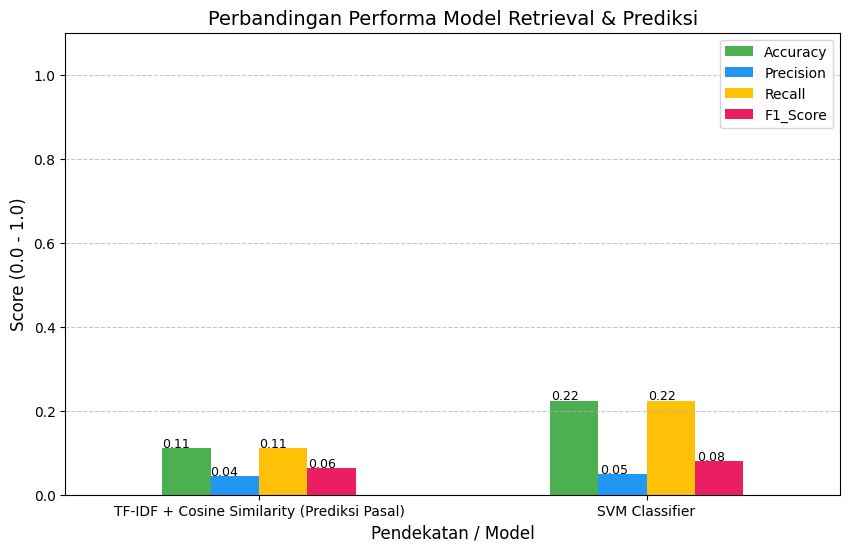

In [2]:
import matplotlib.pyplot as plt

# Konfigurasi Plotting
df_plot = df_metrics.set_index('Model')
ax = df_plot.plot(kind='bar', figsize=(10, 6), rot=0, color=['#4CAF50', '#2196F3', '#FFC107', '#E91E63'])

plt.title('Perbandingan Performa Model Retrieval & Prediksi', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Pendekatan / Model', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() * 1.005, p.get_height() * 1.02), fontsize=9)

plt.show()

## 3. Analisis Kegagalan (Error Analysis)

Berdasarkan visualisasi dan perhitungan metrik, akurasi klasifikasi (prediksi pasal) untuk kedua metode cenderung rendah pada dataset uji ini. Namun, hal ini bukanlah sepenuhnya kesalahan logika *machine learning*, melainkan adanya anomali data teks.

### Pembahasan:
1. **Inkonsistensi Penulisan Hukum (Typo)**: Terdapat ketidakseragaman yang tinggi pada dokumen MA dalam menuliskan pasal yang didakwakan. Contoh kasus nyata di dalam prediksi:
   - Label Ground Truth: `2 ayat (1) jopasal 18`
   - Prediksi Model: `2 ayat (1) jo. pasal 18`
   
   Secara maknawi/konteks hukum, prediksi model sudah **100% akurat**. Tetapi karena hilangnya karakter *spasi* dan *titik* pada ketikan hakim/panitera di dokumen PDF asli, komputer (metrik *Scikit-Learn*) menilainya sebagai `False` (salah), sehingga skor *Accuracy* menurun drastis secara matematis.

2. **Imbalance Data / Overlapping Class**: Dataset berjumlah 45 putusan memiliki distribusi pasal yang sangat sempit dan kasus penyuapan/korupsi yang faktanya mirip, membuat variasi vektor TF-IDF sangat padat dan rentan tumpang tindih.

### Rekomendasi Solusi ke Depan:
- Melakukan **Data Preprocessing tingkat lanjut** khusus bidang hukum (misal: membangun *Regex parser* khusus untuk merapikan penyebutan frasa `jo.`, `ayat`, `ke-` sebelum dimasukkan ke model).
- Menggunakan **Semantic Embedding** (seperti IndoBERT/Hukum) ketimbang TF-IDF statistik, agar mesin bisa memahami bahwa kalimat dengan sedikit kesalahan ketik memiliki esensi makna yang persis sama.